In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
import os
import copy
import json
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [3]:
def build_resnet18_cifar():
    model = models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(512, 10)
    return model

# Load original
model_original = build_resnet18_cifar()
model_original.load_state_dict(
    torch.load('../checkpoints/resnet18_cifar10_best.pth', map_location=device)
)
model_original = model_original.to(device).eval()

# Load pruned models
import torch.nn.utils.prune as prune

def load_pruned_model(sparsity_label):
    m = build_resnet18_cifar()
    # Apply zero pruning to create the mask buffers without changing any weights
    params = [(mod, 'weight') for mod in m.modules()
              if isinstance(mod, (nn.Conv2d, nn.Linear))]
    prune.global_unstructured(params, pruning_method=prune.L1Unstructured, amount=0.0)
    m.load_state_dict(
        torch.load(f'../checkpoints/{sparsity_label}.pth', map_location=device)
    )
    return m.to(device).eval()

model_p30 = load_pruned_model('pruned_30')
model_p50 = load_pruned_model('pruned_50')
model_p70 = load_pruned_model('pruned_70')

# Quantised model runs on CPU only
from torch.quantization import quantize_dynamic
model_quantised = build_resnet18_cifar().to('cpu')
model_quantised = quantize_dynamic(model_quantised, {nn.Linear, nn.Conv2d}, dtype=torch.qint8)
model_quantised.load_state_dict(
    torch.load('../checkpoints/quantised_int8.pth', map_location='cpu')
)
model_quantised.eval()

print("All models loaded.")
print(f"  Original | Pruned 30% | Pruned 50% | Pruned 70% | Quantised INT8")

All models loaded.
  Original | Pruned 30% | Pruned 50% | Pruned 70% | Quantised INT8


C:\Users\naeva\AppData\Local\Temp\ipykernel_15848\3611961110.py:36: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_quantised = quantize_dynamic(model_quantised, {nn.Linear, nn.Conv2d}, dtype=torch.qint8)
d:\experimenting\compression-representation-analysis\venv\Lib\site-packages\torch\_utils.py:445: UserWarning: TypedStorage is deprecated. It will be removed in the 

In [4]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test
)

# CKA needs a reasonably large sample to get stable similarity estimates.
# Kornblith et al. used 1000–5000 samples. We use 1000 which are enough for stable 
# estimates while keeping compute manageable on CPU.
cka_subset = torch.utils.data.Subset(testset, range(1000))
cka_loader = torch.utils.data.DataLoader(
    cka_subset, batch_size=500, shuffle=False, num_workers=0
)

print(f"CKA subset: {len(cka_subset)} samples")

CKA subset: 1000 samples


d:\experimenting\compression-representation-analysis\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [6]:
import sys
import torch
sys.path.append('..')
from src.cka import linear_CKA

# Sanity checks before running on real activations:
# Identical matrices should score 1.0, orthogonal matrices near 0.
X_test = torch.randn(100, 64)
print(f"CKA(X, X) = {linear_CKA(X_test, X_test):.4f}  (expected 1.0)")
print(f"CKA(X, random Y) = {linear_CKA(X_test, torch.randn(100, 64)):.4f}  (expected ~0)")

CKA(X, X) = 1.0000  (expected 1.0)
CKA(X, random Y) = 0.3872  (expected ~0)


In [7]:
def get_activations(model, loader, layer_names, device):
    """
    Extracts flattened activations from named layers using forward hooks.
    
    Returns a dict: {layer_name: tensor of shape (n_samples, n_features)}
    
    We flatten spatial dimensions (H x W) by averaging - this gives one 
    feature vector per image per layer. Global average pooling is standard 
    for comparing convolutional representations across architectures 
    (Kornblith et al. used the same approach).
    """
    activations = {name: [] for name in layer_names}
    hooks = []

    def make_hook(name):
        def hook(module, input, output):
            # output shape: (batch, channels, H, W) for conv layers
            # Global average pool over spatial dims → (batch, channels)
            if output.dim() == 4:
                act = output.mean(dim=[2, 3])
            else:
                act = output
            activations[name].append(act.detach().cpu())
        return hook

    # Register hooks on named layers
    for name, module in model.named_modules():
        if name in layer_names:
            hooks.append(module.register_forward_hook(make_hook(name)))

    model.eval()
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            model(images)

    # Remove hooks after use - leaving them attached leaks memory
    for h in hooks:
        h.remove()

    # Concatenate batches into single matrix per layer
    return {name: torch.cat(acts, dim=0) for name, acts in activations.items()}

# These are the five representational checkpoints we'll probe.
# layer1–4 are ResNet's residual block groups. avgpool is the final 
# global average pooling layer - the representation just before classification.
LAYER_NAMES = ['layer1', 'layer2', 'layer3', 'layer4', 'avgpool']

print("Extracting activations for all models...")
acts_original  = get_activations(model_original,  cka_loader, LAYER_NAMES, device)
acts_p30       = get_activations(model_p30,        cka_loader, LAYER_NAMES, device)
acts_p50       = get_activations(model_p50,        cka_loader, LAYER_NAMES, device)
acts_p70       = get_activations(model_p70,        cka_loader, LAYER_NAMES, device)
acts_quantised = get_activations(model_quantised,  cka_loader, LAYER_NAMES, 'cpu')
print("Done.")

for name in LAYER_NAMES:
    print(f"  {name}: {acts_original[name].shape}")

Extracting activations for all models...
Done.
  layer1: torch.Size([1000, 64])
  layer2: torch.Size([1000, 128])
  layer3: torch.Size([1000, 256])
  layer4: torch.Size([1000, 512])
  avgpool: torch.Size([1000, 512])


In [8]:
# For each compressed model, compute CKA between its activations and 
# the original model's activations at each layer.
# This gives us a similarity profile across the network depth.

models_to_compare = {
    'Pruned 30%':      acts_p30,
    'Pruned 50%':      acts_p50,
    'Pruned 70%':      acts_p70,
    'Quantised INT8':  acts_quantised,
}

cka_scores = {}

for model_name, acts_compressed in models_to_compare.items():
    scores = []
    for layer in LAYER_NAMES:
        orig = acts_original[layer]
        comp = acts_compressed[layer]
        score = linear_CKA(orig, comp)
        scores.append(score)
        print(f"{model_name} | {layer:8s} | CKA = {score:.4f}")
    cka_scores[model_name] = scores
    print()

Pruned 30% | layer1   | CKA = 1.0000
Pruned 30% | layer2   | CKA = 1.0000
Pruned 30% | layer3   | CKA = 0.9999
Pruned 30% | layer4   | CKA = 0.9999
Pruned 30% | avgpool  | CKA = 0.9999

Pruned 50% | layer1   | CKA = 1.0000
Pruned 50% | layer2   | CKA = 0.9997
Pruned 50% | layer3   | CKA = 0.9992
Pruned 50% | layer4   | CKA = 0.9979
Pruned 50% | avgpool  | CKA = 0.9979

Pruned 70% | layer1   | CKA = 0.9998
Pruned 70% | layer2   | CKA = 0.9970
Pruned 70% | layer3   | CKA = 0.9929
Pruned 70% | layer4   | CKA = 0.9786
Pruned 70% | avgpool  | CKA = 0.9786

Quantised INT8 | layer1   | CKA = 1.0000
Quantised INT8 | layer2   | CKA = 1.0000
Quantised INT8 | layer3   | CKA = 1.0000
Quantised INT8 | layer4   | CKA = 1.0000
Quantised INT8 | avgpool  | CKA = 1.0000



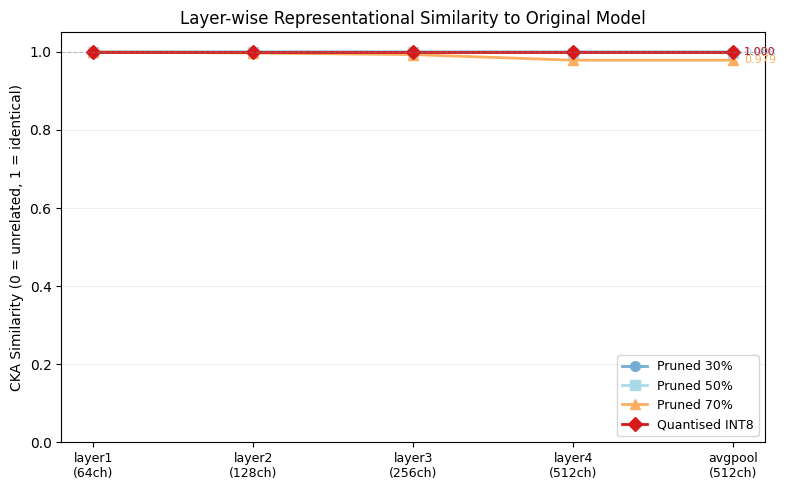

Saved: ../results/figures/cka_similarity_profiles.png


In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

colors    = ['#74add1', '#abd9e9', '#fdae61', '#d7191c']
markers   = ['o', 's', '^', 'D']
x_labels  = ['layer1\n(64ch)', 'layer2\n(128ch)', 'layer3\n(256ch)', 
              'layer4\n(512ch)', 'avgpool\n(512ch)']
x_pos     = list(range(len(LAYER_NAMES)))

for (model_name, scores), color, marker in zip(cka_scores.items(), colors, markers):
    ax.plot(x_pos, scores, marker=marker, color=color,
            linewidth=2, markersize=7, label=model_name)
    # Annotate the final point (avgpool) with the score
    ax.annotate(f'{scores[-1]:.3f}',
                xy=(x_pos[-1], scores[-1]),
                xytext=(8, 0), textcoords='offset points',
                fontsize=8, color=color, va='center')

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, fontsize=9)
ax.set_ylabel('CKA Similarity (0 = unrelated, 1 = identical)')
ax.set_title('Layer-wise Representational Similarity to Original Model')
ax.set_ylim(0, 1.05)
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='y', alpha=0.3, linewidth=0.5)

plt.tight_layout()
os.makedirs('../results/figures', exist_ok=True)
plt.savefig('../results/figures/cka_similarity_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../results/figures/cka_similarity_profiles.png")

In [10]:
cka_output = {
    model_name: {
        layer: round(score, 4)
        for layer, score in zip(LAYER_NAMES, scores)
    }
    for model_name, scores in cka_scores.items()
}

with open('../results/tables/cka_scores.json', 'w') as f:
    json.dump(cka_output, f, indent=2)

print(json.dumps(cka_output, indent=2))

{
  "Pruned 30%": {
    "layer1": 1.0,
    "layer2": 1.0,
    "layer3": 0.9999,
    "layer4": 0.9999,
    "avgpool": 0.9999
  },
  "Pruned 50%": {
    "layer1": 1.0,
    "layer2": 0.9997,
    "layer3": 0.9992,
    "layer4": 0.9979,
    "avgpool": 0.9979
  },
  "Pruned 70%": {
    "layer1": 0.9998,
    "layer2": 0.997,
    "layer3": 0.9929,
    "layer4": 0.9786,
    "avgpool": 0.9786
  },
  "Quantised INT8": {
    "layer1": 1.0,
    "layer2": 1.0,
    "layer3": 1.0,
    "layer4": 1.0,
    "avgpool": 1.0
  }
}


In [11]:
# ResNet-18 has 2 BasicBlocks per layer group - 8 total.
# Probing at this granularity catches divergence that group-level 
# averaging misses, particularly in early layers where spatial 
# features are most compressed.
BLOCK_NAMES = [
    'layer1.0', 'layer1.1',
    'layer2.0', 'layer2.1',
    'layer3.0', 'layer3.1',
    'layer4.0', 'layer4.1',
    'avgpool'
]

print("Extracting block-level activations...")
acts_blocks_original  = get_activations(model_original,  cka_loader, BLOCK_NAMES, device)
acts_blocks_p30       = get_activations(model_p30,        cka_loader, BLOCK_NAMES, device)
acts_blocks_p50       = get_activations(model_p50,        cka_loader, BLOCK_NAMES, device)
acts_blocks_p70       = get_activations(model_p70,        cka_loader, BLOCK_NAMES, device)
acts_blocks_quantised = get_activations(model_quantised,  cka_loader, BLOCK_NAMES, 'cpu')
print("Done.")

for name in BLOCK_NAMES:
    print(f"  {name}: {acts_blocks_original[name].shape}")

Extracting block-level activations...
Done.
  layer1.0: torch.Size([1000, 64])
  layer1.1: torch.Size([1000, 64])
  layer2.0: torch.Size([1000, 128])
  layer2.1: torch.Size([1000, 128])
  layer3.0: torch.Size([1000, 256])
  layer3.1: torch.Size([1000, 256])
  layer4.0: torch.Size([1000, 512])
  layer4.1: torch.Size([1000, 512])
  avgpool: torch.Size([1000, 512])


In [12]:
acts_blocks_compressed = {
    'Pruned 30%':     acts_blocks_p30,
    'Pruned 50%':     acts_blocks_p50,
    'Pruned 70%':     acts_blocks_p70,
    'Quantised INT8': acts_blocks_quantised,
}

cka_block_scores = {}

for model_name, acts_comp in acts_blocks_compressed.items():
    scores = []
    for block in BLOCK_NAMES:
        score = linear_CKA(acts_blocks_original[block], acts_comp[block])
        scores.append(score)
        print(f"{model_name} | {block:12s} | CKA = {score:.4f}")
    cka_block_scores[model_name] = scores
    print()

Pruned 30% | layer1.0     | CKA = 1.0000
Pruned 30% | layer1.1     | CKA = 1.0000
Pruned 30% | layer2.0     | CKA = 1.0000
Pruned 30% | layer2.1     | CKA = 1.0000
Pruned 30% | layer3.0     | CKA = 1.0000
Pruned 30% | layer3.1     | CKA = 0.9999
Pruned 30% | layer4.0     | CKA = 0.9999
Pruned 30% | layer4.1     | CKA = 0.9999
Pruned 30% | avgpool      | CKA = 0.9999

Pruned 50% | layer1.0     | CKA = 1.0000
Pruned 50% | layer1.1     | CKA = 1.0000
Pruned 50% | layer2.0     | CKA = 1.0000
Pruned 50% | layer2.1     | CKA = 0.9997
Pruned 50% | layer3.0     | CKA = 0.9998
Pruned 50% | layer3.1     | CKA = 0.9992
Pruned 50% | layer4.0     | CKA = 0.9986
Pruned 50% | layer4.1     | CKA = 0.9979
Pruned 50% | avgpool      | CKA = 0.9979

Pruned 70% | layer1.0     | CKA = 1.0000
Pruned 70% | layer1.1     | CKA = 0.9998
Pruned 70% | layer2.0     | CKA = 0.9995
Pruned 70% | layer2.1     | CKA = 0.9970
Pruned 70% | layer3.0     | CKA = 0.9974
Pruned 70% | layer3.1     | CKA = 0.9929
Pruned 70% | l

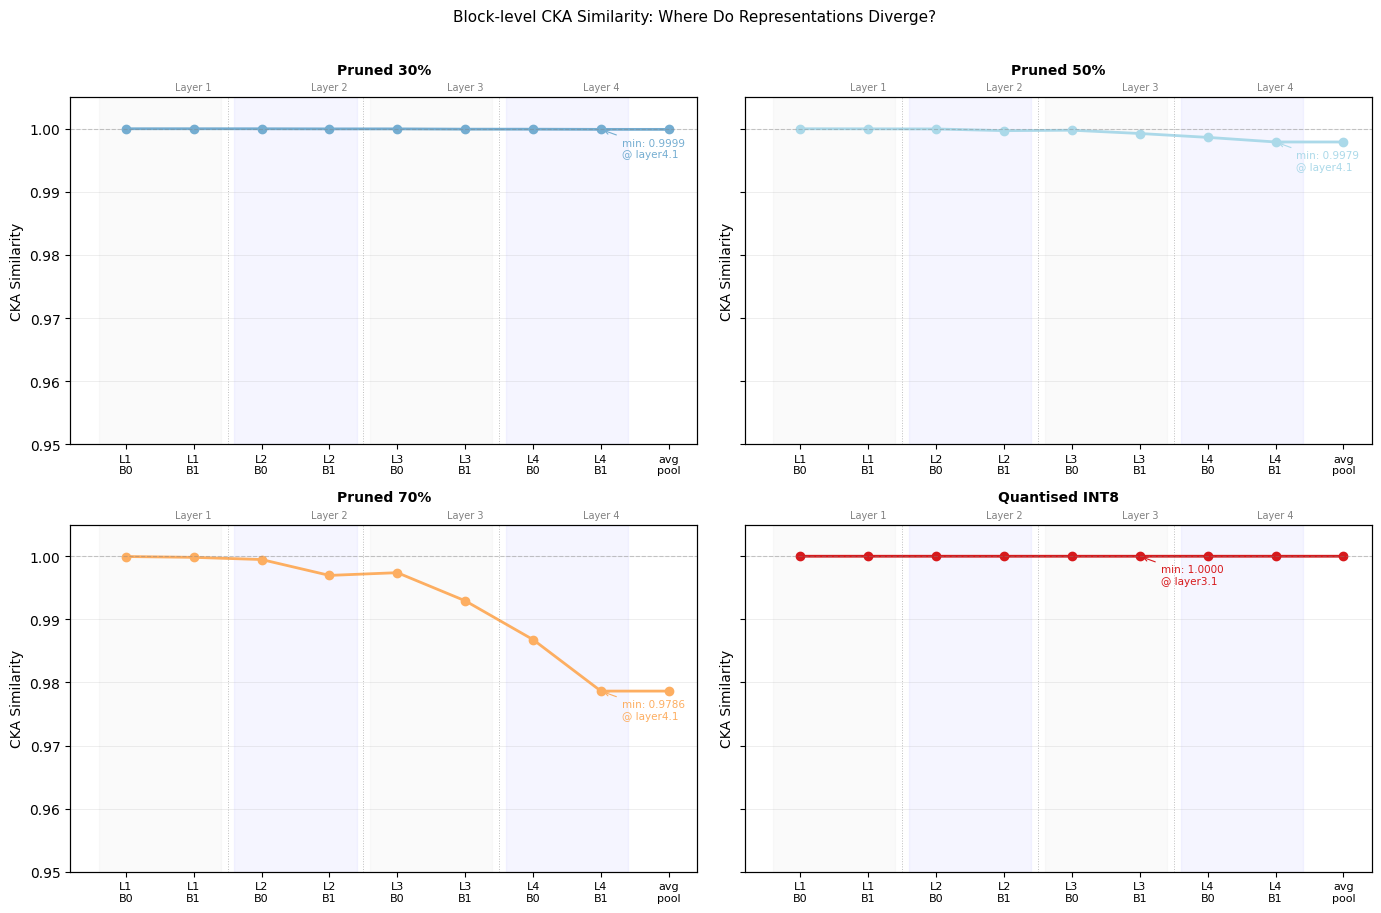

Saved: ../results/figures/cka_block_level.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)
axes = axes.flatten()

x_labels = [b.replace('layer', 'L').replace('.', '\nB') 
             for b in BLOCK_NAMES[:-1]] + ['avg\npool']
x_pos = list(range(len(BLOCK_NAMES)))

layer_boundaries = [2, 4, 6]

model_colors = {
    'Pruned 30%':     '#74add1',
    'Pruned 50%':     '#abd9e9',
    'Pruned 70%':     '#fdae61',
    'Quantised INT8': '#d7191c',
}

for ax, (model_name, scores) in zip(axes, cka_block_scores.items()):
    color = model_colors[model_name]
    ax.plot(x_pos, scores, marker='o', color=color,
            linewidth=2, markersize=6)

    # Shade layer group regions for readability
    for i, (start, end) in enumerate([(0,2),(2,4),(4,6),(6,8)]):
        ax.axvspan(start - 0.4, end - 0.6, alpha=0.04,
                   color='gray' if i % 2 == 0 else 'blue')

    # Mark layer boundaries
    for b in layer_boundaries:
        ax.axvline(x=b - 0.5, color='gray', linestyle=':', linewidth=0.7, alpha=0.5)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, fontsize=8)
    ax.set_ylim(0.95, 1.005)   # zoom in — differences are subtle
    ax.set_title(model_name, fontsize=10, fontweight='bold')
    ax.set_ylabel('CKA Similarity')
    ax.grid(axis='y', alpha=0.3, linewidth=0.5)
    ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.4)

    # Annotate min score — the most informative single number per model
    min_idx = scores.index(min(scores))
    ax.annotate(f'min: {scores[min_idx]:.4f}\n@ {BLOCK_NAMES[min_idx]}',
                xy=(min_idx, scores[min_idx]),
                xytext=(15, -20), textcoords='offset points',
                fontsize=7.5, color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=0.8))

# Add layer group labels at top
for ax in axes:
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks([1, 3, 5, 7, 8.2])
    ax2.set_xticklabels(['Layer 1', 'Layer 2', 'Layer 3', 'Layer 4', ''],
                         fontsize=7, color='gray')
    ax2.tick_params(length=0)

plt.suptitle('Block-level CKA Similarity: Where Do Representations Diverge?',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('../results/figures/cka_block_level.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../results/figures/cka_block_level.png")

In [14]:
cka_block_output = {
    model_name: {
        block: round(score, 4)
        for block, score in zip(BLOCK_NAMES, scores)
    }
    for model_name, scores in cka_block_scores.items()
}

with open('../results/tables/cka_block_scores.json', 'w') as f:
    json.dump(cka_block_output, f, indent=2)

print(json.dumps(cka_block_output, indent=2))

{
  "Pruned 30%": {
    "layer1.0": 1.0,
    "layer1.1": 1.0,
    "layer2.0": 1.0,
    "layer2.1": 1.0,
    "layer3.0": 1.0,
    "layer3.1": 0.9999,
    "layer4.0": 0.9999,
    "layer4.1": 0.9999,
    "avgpool": 0.9999
  },
  "Pruned 50%": {
    "layer1.0": 1.0,
    "layer1.1": 1.0,
    "layer2.0": 1.0,
    "layer2.1": 0.9997,
    "layer3.0": 0.9998,
    "layer3.1": 0.9992,
    "layer4.0": 0.9986,
    "layer4.1": 0.9979,
    "avgpool": 0.9979
  },
  "Pruned 70%": {
    "layer1.0": 1.0,
    "layer1.1": 0.9998,
    "layer2.0": 0.9995,
    "layer2.1": 0.997,
    "layer3.0": 0.9974,
    "layer3.1": 0.9929,
    "layer4.0": 0.9868,
    "layer4.1": 0.9786,
    "avgpool": 0.9786
  },
  "Quantised INT8": {
    "layer1.0": 1.0,
    "layer1.1": 1.0,
    "layer2.0": 1.0,
    "layer2.1": 1.0,
    "layer3.0": 1.0,
    "layer3.1": 1.0,
    "layer4.0": 1.0,
    "layer4.1": 1.0,
    "avgpool": 1.0
  }
}


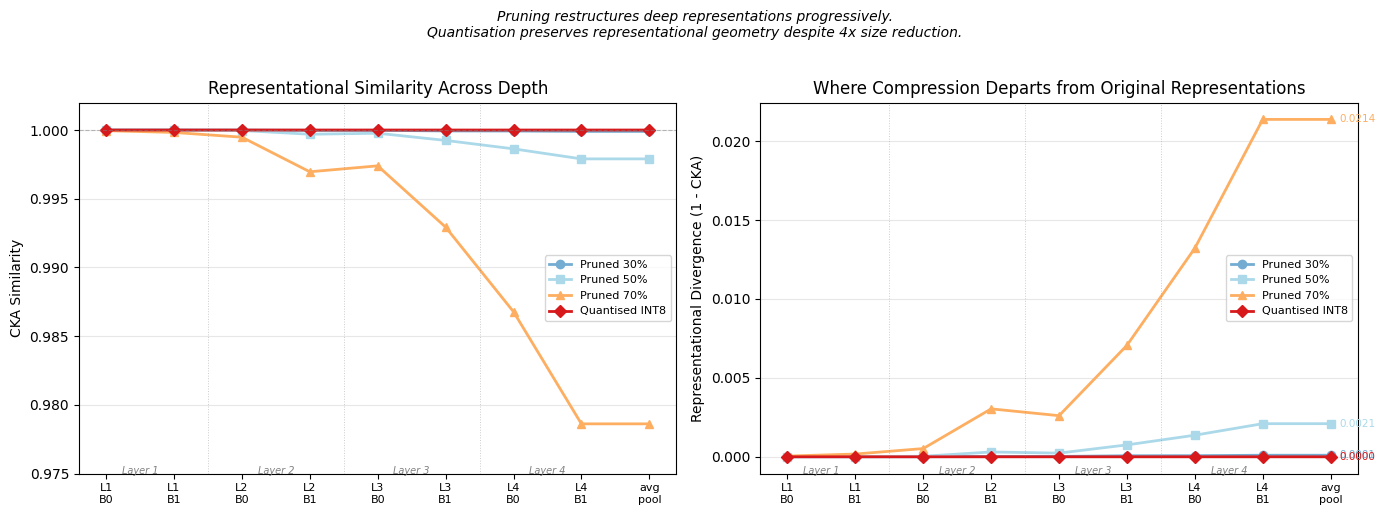

Saved: ../results/figures/cka_divergence_comparison.png


In [15]:
# Plot all four models on one axis to make the contrast explicit.
# We invert the axis: showing (1 - CKA) makes divergence visually clearer 
# than similarity, since the interesting differences all live near 1.0.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors  = ['#74add1', '#abd9e9', '#fdae61', '#d7191c']
markers = ['o', 's', '^', 'D']
x_labels = [b.replace('layer', 'L').replace('.', '\nB')
             for b in BLOCK_NAMES[:-1]] + ['avg\npool']
x_pos = list(range(len(BLOCK_NAMES)))

# Left: raw CKA similarity — the standard view
for (model_name, scores), color, marker in zip(cka_block_scores.items(), colors, markers):
    ax1.plot(x_pos, scores, marker=marker, color=color,
             linewidth=2, markersize=6, label=model_name)

ax1.set_xticks(x_pos)
ax1.set_xticklabels(x_labels, fontsize=8)
ax1.set_ylim(0.975, 1.002)
ax1.set_ylabel('CKA Similarity')
ax1.set_title('Representational Similarity Across Depth')
ax1.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.3)

for b in [2, 4, 6]:
    ax1.axvline(x=b - 0.5, color='gray', linestyle=':', linewidth=0.7, alpha=0.4)

# Right: representational divergence (1 - CKA), log scale
# This is the more honest view - it shows *how much* each method 
# departs from the original, not how much it preserves.
for (model_name, scores), color, marker in zip(cka_block_scores.items(), colors, markers):
    divergence = [1 - s for s in scores]
    ax2.plot(x_pos, divergence, marker=marker, color=color,
             linewidth=2, markersize=6, label=model_name)
    # Annotate final divergence value
    ax2.annotate(f'{divergence[-1]:.4f}',
                 xy=(x_pos[-1], divergence[-1]),
                 xytext=(6, 0), textcoords='offset points',
                 fontsize=7.5, color=color, va='center')

ax2.set_xticks(x_pos)
ax2.set_xticklabels(x_labels, fontsize=8)
ax2.set_ylabel('Representational Divergence (1 - CKA)')
ax2.set_title('Where Compression Departs from Original Representations')
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.3)

for b in [2, 4, 6]:
    ax2.axvline(x=b - 0.5, color='gray', linestyle=':', linewidth=0.7, alpha=0.4)

# Layer group labels
for ax in [ax1, ax2]:
    for x, label in zip([0.5, 2.5, 4.5, 6.5], ['Layer 1', 'Layer 2', 'Layer 3', 'Layer 4']):
        ax.text(x, ax.get_ylim()[0], label, ha='center', fontsize=7,
                color='gray', style='italic')

plt.suptitle(
    'Pruning restructures deep representations progressively.\n'
    'Quantisation preserves representational geometry despite 4x size reduction.',
    fontsize=10, style='italic', y=1.02
)

plt.tight_layout()
plt.savefig('../results/figures/cka_divergence_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../results/figures/cka_divergence_comparison.png")

In [ ]:
# Compute where each model's maximum divergence occurs
findings = {}
for model_name, scores in cka_block_scores.items():
    divergences = [1 - s for s in scores]
    max_div_idx = divergences.index(max(divergences))
    findings[model_name] = {
        "min_cka":            round(min(scores), 4),
        "max_divergence":     round(max(divergences), 4),
        "divergence_peak_at": BLOCK_NAMES[max_div_idx],
        "divergence_pattern": "monotonic_deep" if max_div_idx >= 6 else
                              "early_onset"    if max_div_idx <= 3 else
                              "mid_onset"
    }

with open('../results/tables/findings_summary.json', 'w') as f:
    json.dump(findings, f, indent=2)

print(json.dumps(findings, indent=2))